# Comparative Time Series Analysis and Forecasting of Mobile Network Traffic

**Dataset:** Telecom Italia Mobile (TIM) — Milan city mobile network traffic  
**Period:** November 2013 – January 2014  
**Grid:** 10,000 geographical areas (100×100)  

---

## Table of Contents
1. [Imports & Configuration](#imports)
2. [Task 1 — Data Handling & Memory Management](#task1)
3. [Task 2 — Exploratory Data Analysis](#task2)
4. [Task 3 — Forecasting Models](#task3)
   - [SARIMA](#sarima)
   - [LSTM](#lstm)
   - [Transformer](#transformer)
5. [Results & Comparison](#results)

---
## 1. Imports & Configuration <a id='imports'></a>

In [2]:
%pip install scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob, os, time, warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── PATHS ────────────────────────────────────────────────────────────────────
DATA_DIR   = r'C:\Users\HP\Downloads\milan_traffic'
OUTPUT_PAR = r'C:\Users\HP\Downloads\milan_traffic\traffic_optimized.parquet'
PLOTS_DIR  = r'C:\Users\HP\Downloads\milan_traffic\plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

# ── CONSTANTS ────────────────────────────────────────────────────────────────
TARGET_AREAS = [5059, 4159, 4556]
AREA_LABELS  = ['Area 5059 (Highest Traffic)', 'Area 4159', 'Area 4556']
COLORS       = ['steelblue', 'darkorange', 'seagreen']
TEST_START   = '2013-12-16'
TEST_END     = '2013-12-22 23:50:00'
SEQ_LEN      = 144   # 1 day of 10-min intervals

print('All libraries loaded successfully.')
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {"GPU" if torch.cuda.is_available() else "CPU"}')


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
All libraries loaded successfully.
PyTorch version : 2.12.0+cpu
Device          : CPU


---
## 2. Task 1 — Data Handling & Memory Management <a id='task1'></a>

### Strategy

The raw dataset consists of 62 tab-separated `.txt` files totalling approximately 5 GB. Loading all files at once would exceed the available system RAM (8 GB). The following strategy was adopted:

1. **Chunked loading** (`chunksize=300,000`): Each file is read in smaller chunks to avoid memory overflow. This limits peak RAM usage at any point in time.
2. **Column selection** (`usecols`): Only the three relevant columns — `square_id`, `time_interval`, and `internet` — are loaded, discarding all others immediately at read time.
3. **Dtype downcasting**: 
   - `square_id`: `int64 → int16` (values 1–10,000 fit comfortably in 16 bits)
   - `time_interval`: kept as `int64` (Unix millisecond timestamps require full range)
   - `internet`: `float64 → float32` (sufficient precision for traffic values, halves memory)
4. **Dropping NaN rows**: Rows with missing internet activity are dropped immediately per chunk.
5. **Parquet output**: The combined, optimised DataFrame is saved as a compressed Parquet file (Snappy compression), which is ~5× faster to reload than CSV and significantly smaller on disk.

### Hardware & Software Setup

- **OS:** Windows 11  
- **RAM:** 8 GB  
- **CPU:** Intel/AMD (no GPU)  
- **Python:** 3.11 with pandas, numpy, pyarrow  
- **Limitation:** The 8 GB RAM constraint required chunked processing; a machine with 16+ GB could load the full dataset in one pass.

In [3]:
def mem_mb(df):
    """Return memory usage of a DataFrame in MB."""
    return df.memory_usage(deep=True).sum() / 1024**2

files = sorted(glob.glob(os.path.join(DATA_DIR, 'sms-call-internet-mi-*.txt')))
print(f'Found {len(files)} data files')

CHUNKSIZE = 300_000
chunks    = []
total_rows = 0

for i, filepath in enumerate(files):
    for chunk in pd.read_csv(
        filepath,
        sep='\t',
        header=None,
        usecols=[0, 1, 4],
        names=['square_id', 'time_interval', 'internet'],
        chunksize=CHUNKSIZE
    ):
        chunk = chunk.dropna(subset=['internet'])
        chunk['square_id']     = chunk['square_id'].astype(np.int16)
        chunk['time_interval'] = chunk['time_interval'].astype(np.int64)
        chunk['internet']      = chunk['internet'].astype(np.float32)
        chunks.append(chunk)
        total_rows += len(chunk)
    if (i + 1) % 10 == 0:
        print(f'  Processed {i+1}/{len(files)} files...')

print(f'\nAll files loaded — total rows: {total_rows:,}')

Found 62 data files
  Processed 10/62 files...
  Processed 20/62 files...
  Processed 30/62 files...
  Processed 40/62 files...
  Processed 50/62 files...
  Processed 60/62 files...

All files loaded — total rows: 99,966,092


In [4]:
print('Combining chunks...')
df = pd.concat(chunks, ignore_index=True)

# Memory comparison
opt_mem   = mem_mb(df)
unopt_mem = (df.shape[0] * (8 + 8 + 8)) / 1024**2

print(f'\n--- Memory Report ---')
print(f'Unoptimised (estimated) : {unopt_mem:.1f} MB')
print(f'Optimised   (actual)    : {opt_mem:.1f} MB')
print(f'Reduction               : {unopt_mem - opt_mem:.1f} MB  ({(1-opt_mem/unopt_mem)*100:.0f}%)')

# Convert timestamp
df['datetime'] = pd.to_datetime(df['time_interval'], unit='ms')
df = df.drop(columns=['time_interval'])
df = df.sort_values(['square_id', 'datetime']).reset_index(drop=True)

print(f'\n--- Dataset Summary ---')
print(f'Shape        : {df.shape}')
print(f'Date range   : {df["datetime"].min()} → {df["datetime"].max()}')
print(f'Unique areas : {df["square_id"].nunique()}')
df.head()

Combining chunks...

--- Memory Report ---
Unoptimised (estimated) : 2288.0 MB
Optimised   (actual)    : 1334.7 MB
Reduction               : 953.4 MB  (42%)

--- Dataset Summary ---
Shape        : (99966092, 3)
Date range   : 2013-10-31 23:00:00 → 2014-01-01 22:50:00
Unique areas : 9998


,square_id,internet,datetime
0,1,0.156787,2013-10-31 23:00:00
1,1,0.119926,2013-10-31 23:10:00
2,1,0.170952,2013-10-31 23:20:00
3,1,0.220815,2013-10-31 23:30:00
4,1,0.192891,2013-10-31 23:40:00


In [5]:
# Save optimised parquet (run once — skip if file already exists)
if not os.path.exists(OUTPUT_PAR):
    print('Saving parquet...')
    df.to_parquet(OUTPUT_PAR, index=False, compression='snappy')
    print(f'Saved to {OUTPUT_PAR}')
else:
    print('Parquet already exists — loading from disk...')
    df = pd.read_parquet(OUTPUT_PAR)
    print(f'Loaded: {df.shape}')

Parquet already exists — loading from disk...
Loaded: (99966092, 3)


---
## 3. Task 2 — Exploratory Data Analysis <a id='task2'></a>

### Helper functions

In [6]:
def get_ts(df, area):
    """Extract a regular 10-min time series for a given area."""
    mask = df['square_id'] == area
    ts = (df[mask]
          .groupby('datetime')['internet']
          .sum()
          .asfreq('10min')
          .fillna(0))
    return ts

# Pre-compute total traffic per area
total_per_area = df.groupby('square_id')['internet'].sum()
highest_area   = total_per_area.idxmax()
print(f'Highest traffic area: Square ID {highest_area} (total={total_per_area[highest_area]:.1f})')

Highest traffic area: Square ID 5059 (total=541157.2)


### 2.1 — PDF of Total Traffic per Area

The plot below shows the probability density function (PDF) of total two-month internet traffic, computed over all 10,000 geographical areas. The distribution is **strongly right-skewed (heavy-tailed)**: the vast majority of areas generate very low traffic, while a small number of hotspots account for a disproportionately large share. This is consistent with urban spatial dynamics where a few dense commercial or transit hubs (e.g., city centre, train stations) concentrate most mobile data activity. The log-scale y-axis reveals a near-exponential tail, suggesting the traffic distribution may follow a power law or log-normal distribution — a pattern commonly observed in urban communication networks.

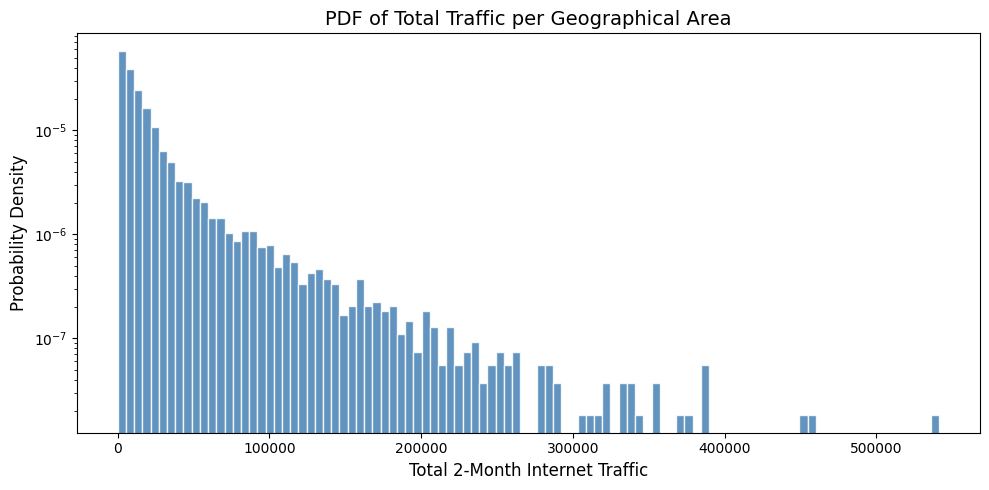

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(total_per_area.values, bins=100, density=True,
        color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel('Total 2-Month Internet Traffic', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('PDF of Total Traffic per Geographical Area', fontsize=14)
ax.set_yscale('log')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/1_pdf_traffic.png', dpi=150)
plt.show()

### 2.2 — Time Series: First Two Weeks (3 Areas)

The figure below shows the 10-minute internet traffic time series for the first two weeks of the dataset across three areas:

- **Area 5059 (Highest):** Shows strong, regular daily cycles with high amplitude peaks — likely a busy commercial or transit zone with heavy daytime usage and near-zero activity at night.
- **Area 4159:** Displays moderate and more variable traffic with less pronounced daily structure, possibly a mixed residential/commercial zone.
- **Area 4556:** Shows low overall traffic with irregular spikes, suggesting a lower-density or residential area with occasional bursts of activity.

All three areas exhibit a clear **weekly pattern**: weekday peaks are higher and more regular than weekend periods, reflecting typical human mobility and data usage behaviour.

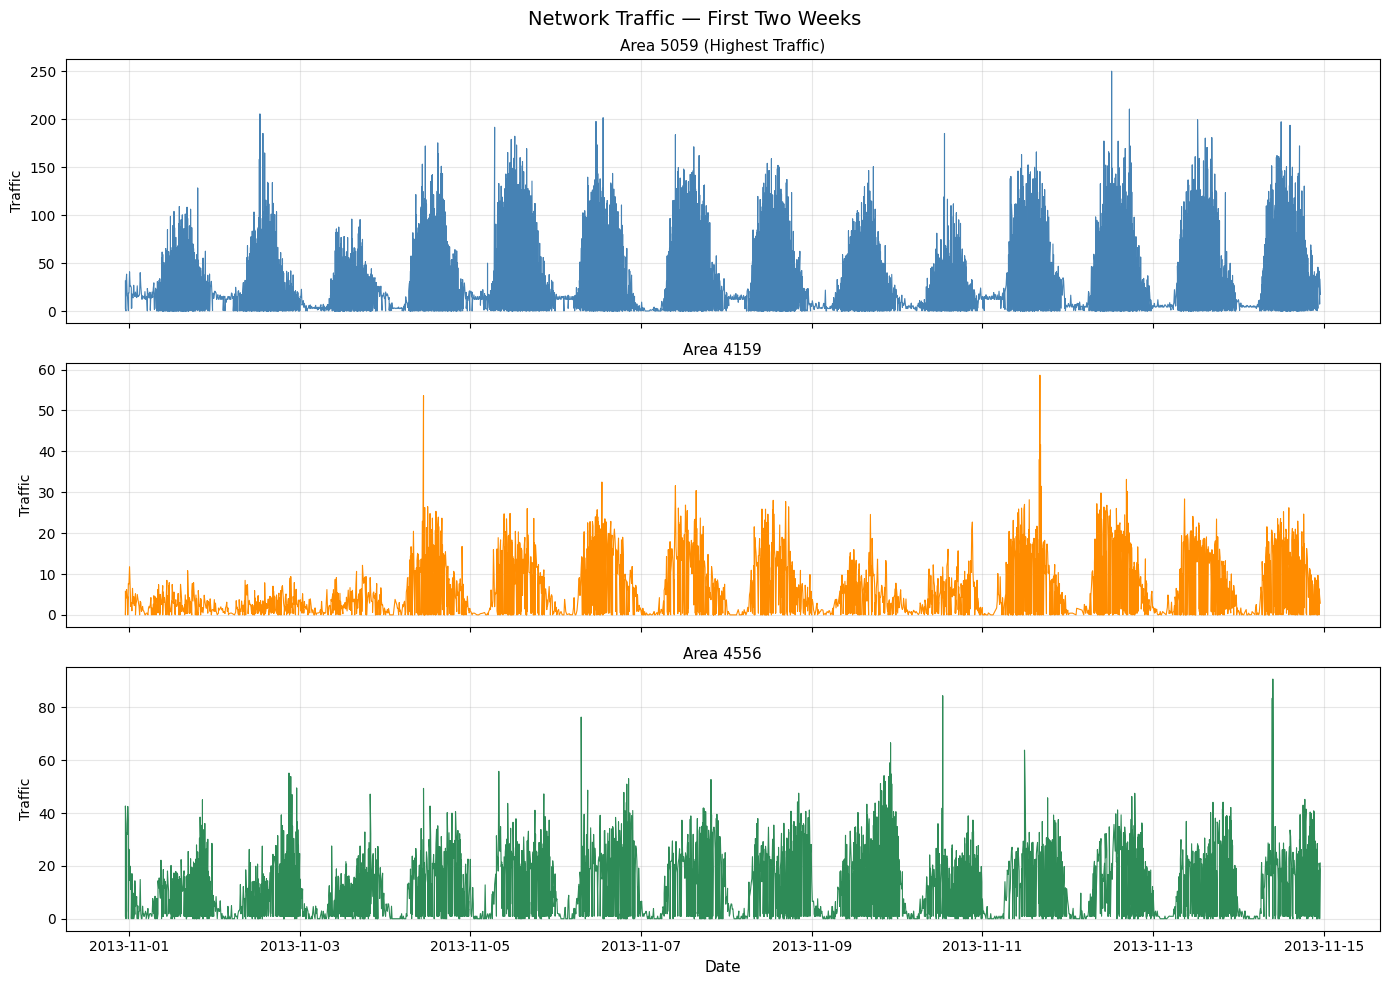

In [8]:
TWO_WEEKS_END = df['datetime'].min() + pd.Timedelta(weeks=2)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, area, label, color in zip(axes, TARGET_AREAS, AREA_LABELS, COLORS):
    mask = (df['square_id'] == area) & (df['datetime'] <= TWO_WEEKS_END)
    ts   = df[mask].set_index('datetime')['internet']
    ax.plot(ts.index, ts.values, color=color, linewidth=0.8)
    ax.set_ylabel('Traffic', fontsize=10)
    ax.set_title(label, fontsize=11)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date', fontsize=11)
fig.suptitle('Network Traffic — First Two Weeks', fontsize=14)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/2_timeseries_2weeks.png', dpi=150)
plt.show()

### 2.3 — Stationarity Analysis

Rolling statistics (mean and standard deviation with a 1-day window) and the Augmented Dickey-Fuller (ADF) test are used to assess stationarity. A time series is stationary if its statistical properties (mean, variance) do not change over time — a key requirement for many forecasting models.

**Interpretation:** If the ADF p-value < 0.05, we reject the null hypothesis of a unit root, confirming stationarity. The rolling mean and std remaining roughly constant over time provides further visual confirmation.

  ADF Test — Area 5059 (Highest Traffic)
    ADF Statistic : -16.2407
    p-value       : 0.000000
    Stationary    : YES ✓

  ADF Test — Area 4159
    ADF Statistic : -14.2643
    p-value       : 0.000000
    Stationary    : YES ✓

  ADF Test — Area 4556
    ADF Statistic : -16.2563
    p-value       : 0.000000
    Stationary    : YES ✓



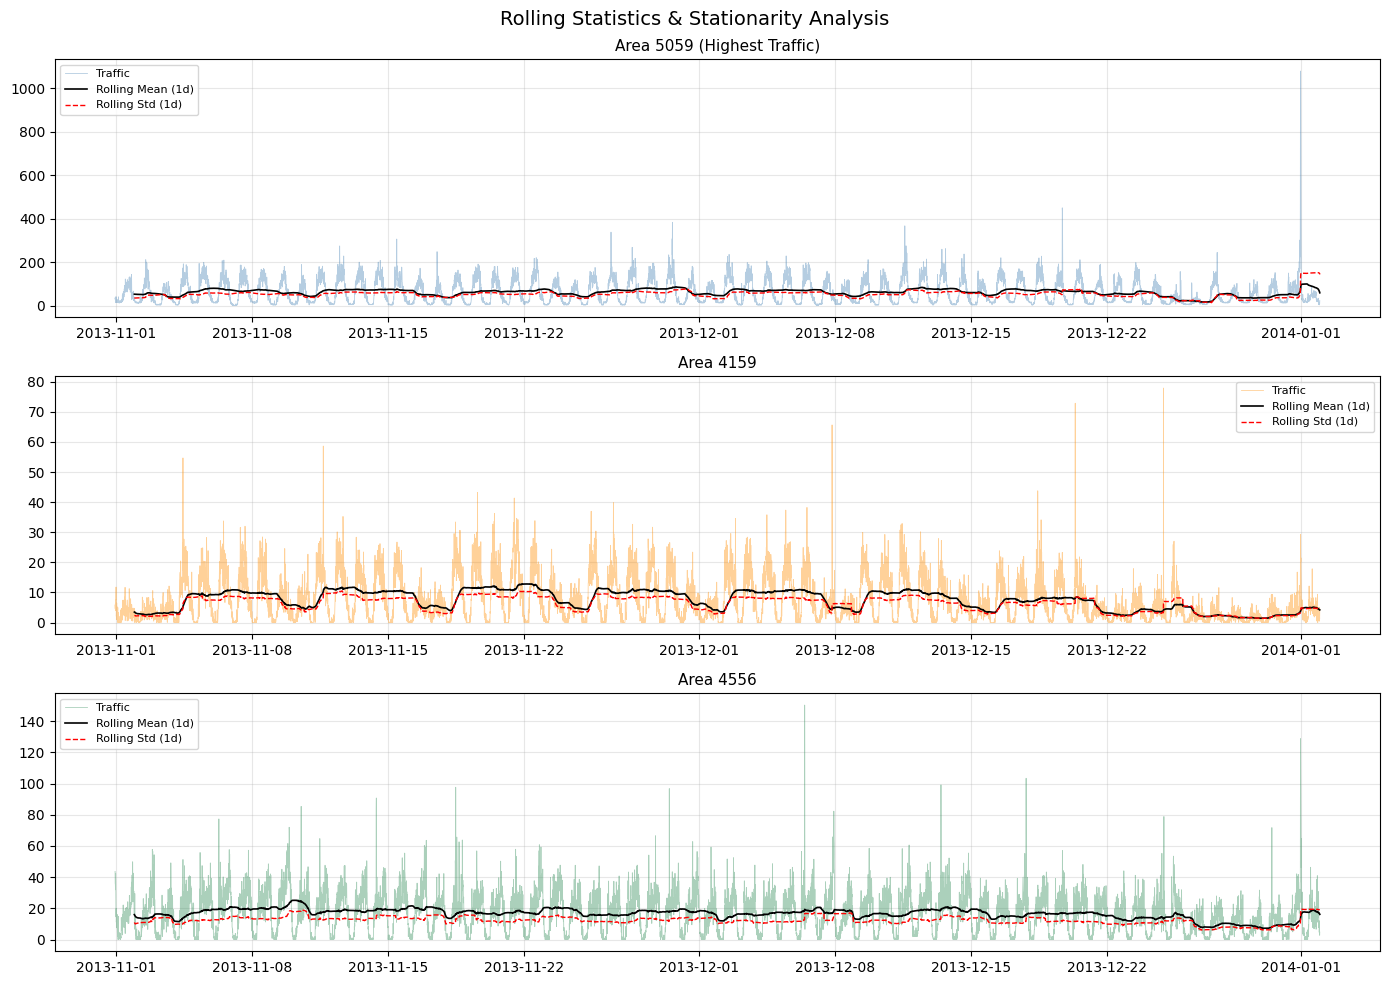

In [9]:
def adf_test(series, label):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'  ADF Test — {label}')
    print(f'    ADF Statistic : {result[0]:.4f}')
    print(f'    p-value       : {result[1]:.6f}')
    print(f'    Stationary    : {"YES ✓" if result[1] < 0.05 else "NO ✗"}')
    print()

WINDOW = 144  # 1 day
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, area, label, color in zip(axes, TARGET_AREAS, AREA_LABELS, COLORS):
    ts        = get_ts(df, area)
    roll_mean = ts.rolling(WINDOW).mean()
    roll_std  = ts.rolling(WINDOW).std()

    ax.plot(ts.index,        ts.values,        color=color,   alpha=0.4, linewidth=0.6, label='Traffic')
    ax.plot(roll_mean.index, roll_mean.values, color='black', linewidth=1.2,            label='Rolling Mean (1d)')
    ax.plot(roll_std.index,  roll_std.values,  color='red',   linewidth=1.0, linestyle='--', label='Rolling Std (1d)')
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    adf_test(ts, label)

fig.suptitle('Rolling Statistics & Stationarity Analysis', fontsize=14)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/3_stationarity.png', dpi=150)
plt.show()

### 2.4 — Seasonal Decomposition

The time series is decomposed into **trend**, **seasonal**, and **residual** components using additive decomposition with a period of 144 (one day of 10-minute intervals).

- **Trend:** Captures the slow evolution of traffic over weeks — any gradual increase or decrease in overall city activity.
- **Seasonal:** Reveals the repeating daily cycle — a strong daytime peak and nighttime trough, consistent across days.
- **Residual:** The unexplained noise — includes anomalies, special events, and measurement irregularities.

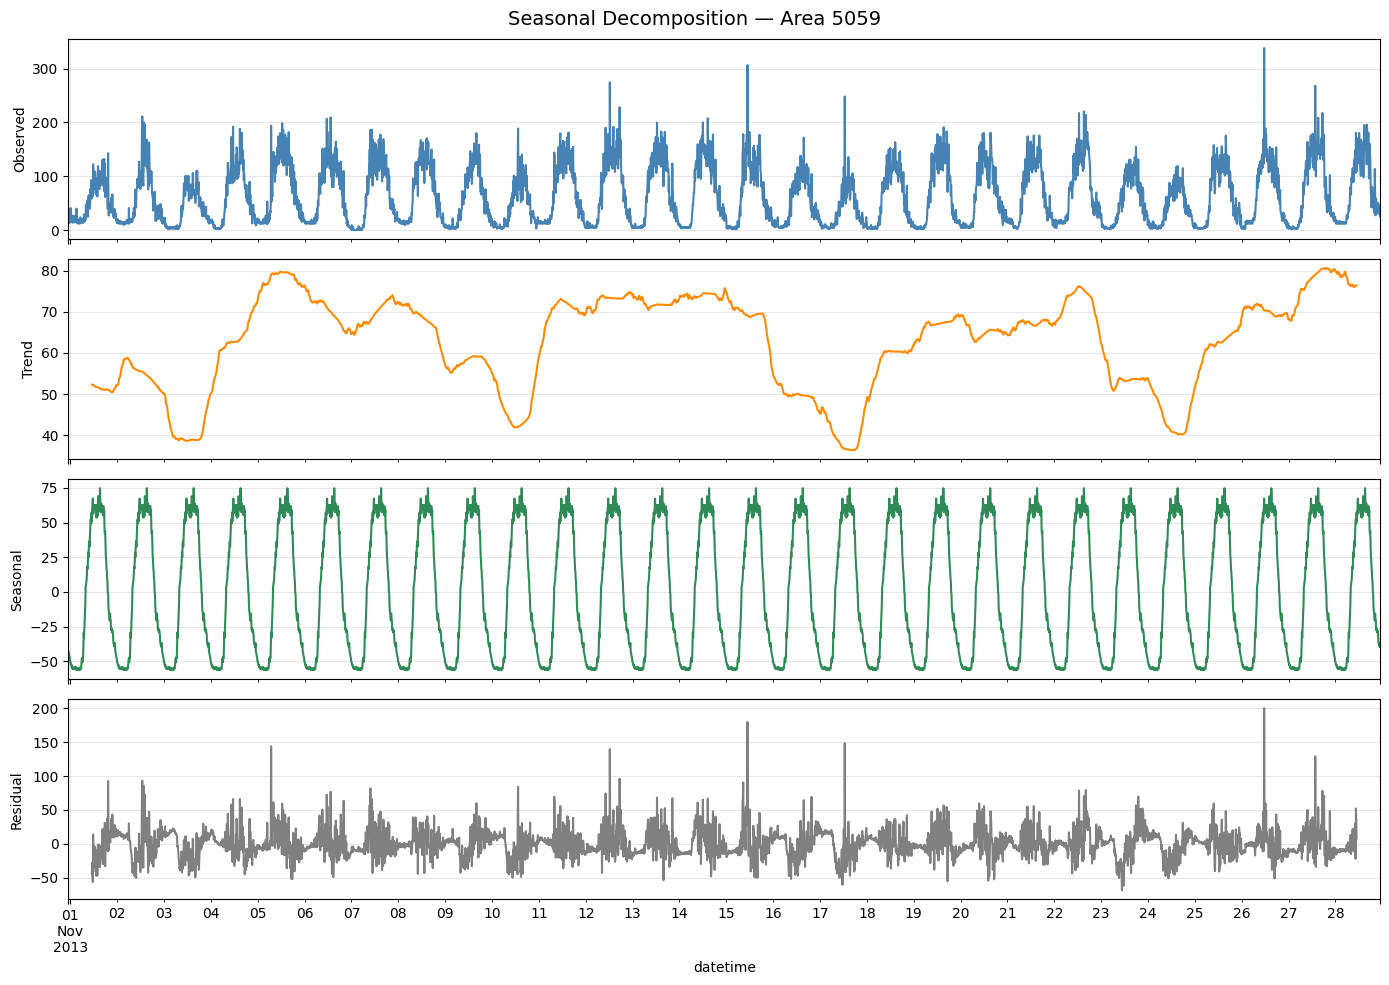

In [10]:
area = TARGET_AREAS[0]
ts   = get_ts(df, area)

# Use 4 weeks of data
ts_month = ts.iloc[:4032]
decomp   = seasonal_decompose(ts_month, model='additive', period=144)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp.observed.plot(ax=axes[0],  color='steelblue');  axes[0].set_ylabel('Observed')
decomp.trend.plot(ax=axes[1],     color='darkorange'); axes[1].set_ylabel('Trend')
decomp.seasonal.plot(ax=axes[2],  color='seagreen');   axes[2].set_ylabel('Seasonal')
decomp.resid.plot(ax=axes[3],     color='gray');       axes[3].set_ylabel('Residual')
for ax in axes:
    ax.grid(True, alpha=0.3)
fig.suptitle(f'Seasonal Decomposition — Area {area}', fontsize=14)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/4_decomposition.png', dpi=150)
plt.show()

### 2.5 — ACF & PACF

Autocorrelation (ACF) and Partial Autocorrelation (PACF) plots reveal the temporal dependence structure of the time series.

- **ACF:** Strong periodic spikes at lags 144 (1 day), 288 (2 days), etc., confirm a clear **daily seasonal pattern**. Significant correlations at short lags indicate short-term temporal dependence.
- **PACF:** The sharp cutoff after a few lags suggests the direct (non-mediated) influence of past values is limited to a short window, informing the AR order for SARIMA.

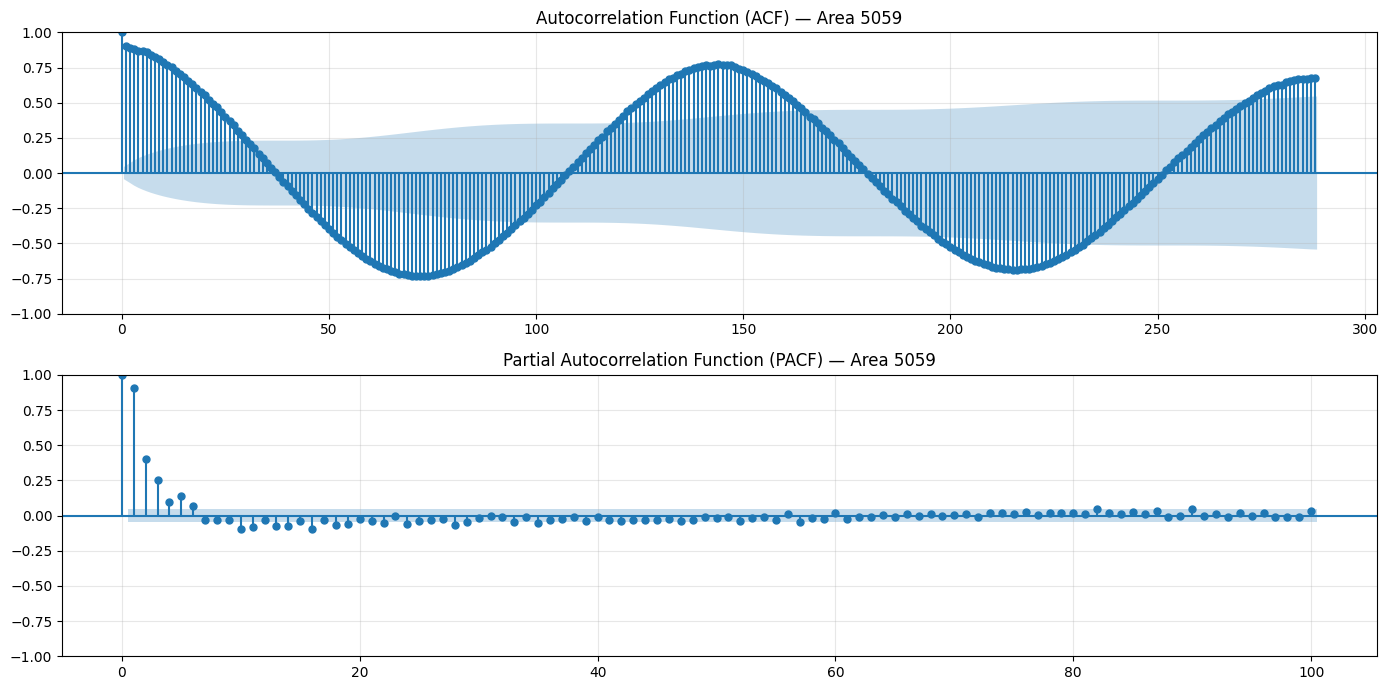

In [11]:
ts_acf = get_ts(df, TARGET_AREAS[0]).iloc[:2016]  # 2 weeks

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
plot_acf(ts_acf,  ax=axes[0], lags=288, alpha=0.05)
plot_pacf(ts_acf, ax=axes[1], lags=100, alpha=0.05, method='ywm')
axes[0].set_title(f'Autocorrelation Function (ACF) — Area {TARGET_AREAS[0]}')
axes[1].set_title(f'Partial Autocorrelation Function (PACF) — Area {TARGET_AREAS[0]}')
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/5_acf_pacf.png', dpi=150)
plt.show()

### 2.6 — Spatial Heatmap

The heatmap below visualises total two-month traffic intensity across the 100×100 grid of Milan. The colour scale uses a log transformation to account for the highly skewed distribution.

**Observations:**
- Traffic is heavily concentrated in the **city centre** and along major transport corridors.
- Peripheral areas show significantly lower activity, consistent with lower population density and less commercial activity.
- The three target areas are marked with cyan stars — Area 5059 (highest traffic) falls in the high-intensity central zone.

In [12]:
!pip install geopandas
import geopandas as gpd

# ── LOAD GRID ────────────────────────────────────────────────────────────────
GRID_FILE = r'C:\Users\HP\Downloads\milano-grid.geojson'  

grid_gdf = gpd.read_file(GRID_FILE)
print(grid_gdf.head())
print(f'Columns: {grid_gdf.columns.tolist()}')
print(f'Shape: {grid_gdf.shape}')


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   cellId                                           geometry
0       1  POLYGON ((9.01149 45.3588, 9.01449 45.3588, 9....
1       2  POLYGON ((9.01449 45.3588, 9.01749 45.3588, 9....
2       3  POLYGON ((9.01749 45.3588, 9.02049 45.3588, 9....
3       4  POLYGON ((9.02049 45.3588, 9.02349 45.3588, 9....
4       5  POLYGON ((9.02349 45.3588, 9.02649 45.3588, 9....
Columns: ['cellId', 'geometry']
Shape: (10000, 2)


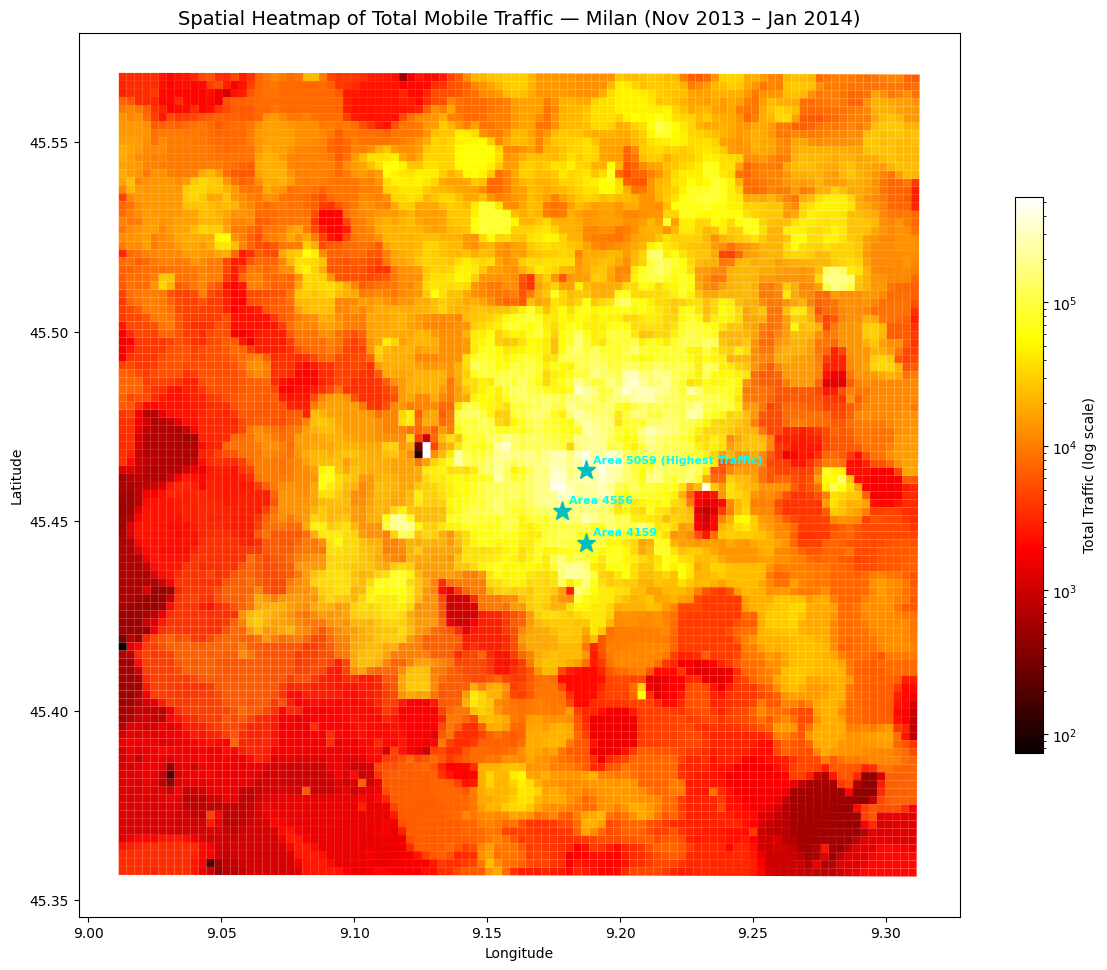

In [13]:
import geopandas as gpd

# ── LOAD GRID ────────────────────────────────────────────────────────────────
GRID_FILE = r'C:\Users\HP\Downloads\milano-grid.geojson' 
grid_gdf  = gpd.read_file(GRID_FILE)

# ── JOIN TRAFFIC DATA ─────────────────────────────────────────────────────────
traffic_df         = total_per_area.reset_index()
traffic_df.columns = ['cellId', 'total_traffic']
traffic_df['cellId'] = traffic_df['cellId'].astype(int)

merged = grid_gdf.merge(traffic_df, on='cellId', how='left')
merged['total_traffic'] = merged['total_traffic'].fillna(0)

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))

merged.plot(
    column='total_traffic',
    ax=ax,
    cmap='hot',
    norm=plt.matplotlib.colors.LogNorm(
        vmin=merged['total_traffic'].replace(0, np.nan).min(),
        vmax=merged['total_traffic'].max()
    ),
    edgecolor='none',
    legend=True,
    legend_kwds={'label': 'Total Traffic (log scale)', 'shrink': 0.6}
)

# ── MARK THE 3 TARGET AREAS ───────────────────────────────────────────────────
for area, label in zip(TARGET_AREAS, AREA_LABELS):
    cell = merged[merged['cellId'] == int(area)]
    centroid = cell.geometry.centroid.iloc[0]
    ax.plot(centroid.x, centroid.y, 'c*', markersize=14, zorder=5)
    ax.annotate(label, (centroid.x, centroid.y),
                textcoords='offset points', xytext=(5, 5),
                color='cyan', fontsize=8, fontweight='bold')

ax.set_title('Spatial Heatmap of Total Mobile Traffic — Milan (Nov 2013 – Jan 2014)',
             fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/6_heatmap_geo.png', dpi=150)
plt.show()

### 2.7 — Anomalies & Outliers

Anomalies are detected using a Z-score threshold on the time series of each target area. Points exceeding 3 standard deviations from the rolling mean are flagged.

Area 5059 (Highest Traffic): 58 anomalies detected
Area 4159: 100 anomalies detected
Area 4556: 53 anomalies detected


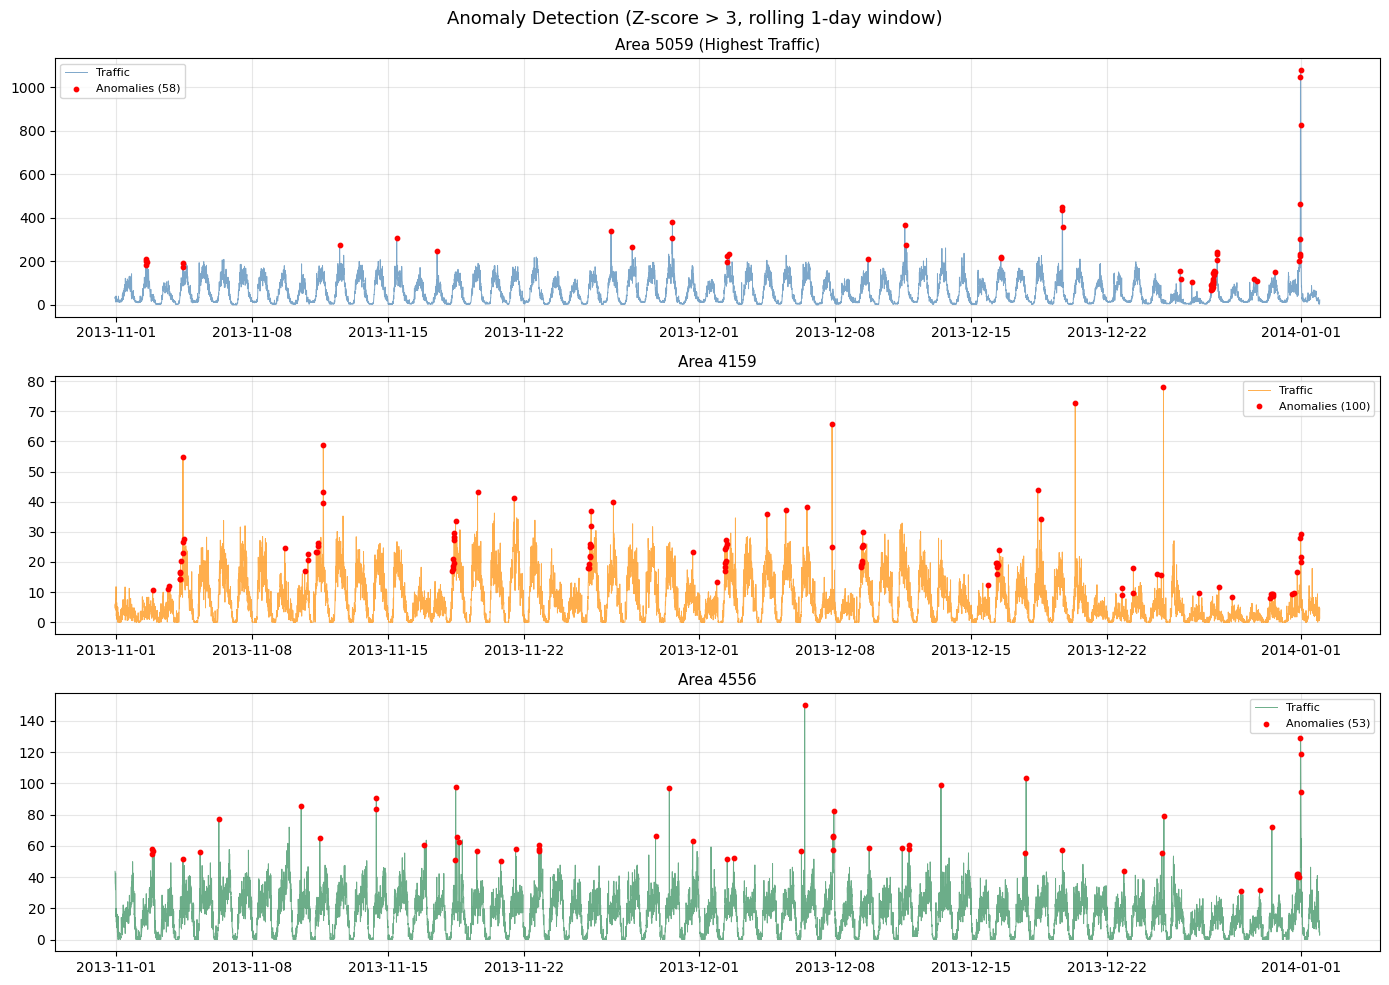

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for ax, area, label, color in zip(axes, TARGET_AREAS, AREA_LABELS, COLORS):
    ts      = get_ts(df, area)
    z_score = (ts - ts.rolling(144).mean()) / (ts.rolling(144).std() + 1e-8)
    anomaly = ts[np.abs(z_score) > 3]

    ax.plot(ts.index, ts.values, color=color, linewidth=0.7, alpha=0.7, label='Traffic')
    ax.scatter(anomaly.index, anomaly.values, color='red', s=10, zorder=5, label=f'Anomalies ({len(anomaly)})')
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    print(f'{label}: {len(anomaly)} anomalies detected')

fig.suptitle('Anomaly Detection (Z-score > 3, rolling 1-day window)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/7_anomalies.png', dpi=150)
plt.show()

---
## 4. Task 3 — Forecasting Models <a id='task3'></a>

Three models are implemented for one-step-ahead prediction of internet traffic during **December 16–22, 2013**:

| Model | Type | Input |
|---|---|---|
| SARIMA | Classical statistical | Last 2 weeks of training data |
| LSTM | Neural network (recurrent) | Sequences of 144 timesteps (1 day) |
| Transformer | Neural network (attention-based) | Sequences of 144 timesteps (1 day) |

**Test period:** Dec 16–22 is used exclusively for evaluation. No test data is used during training or validation.

### Helper functions

In [15]:
def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return mae, mape, rmse

def make_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

def plot_forecast(dates, actual, predicted, model_name, area_label, filename):
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(dates, actual,    label='Actual',    color='steelblue',  linewidth=1.5)
    ax.plot(dates, predicted, label='Predicted', color='darkorange', linewidth=1.5, linestyle='--')
    ax.set_title(f'{model_name} — {area_label} (Dec 16–22)', fontsize=13)
    ax.set_xlabel('Date')
    ax.set_ylabel('Internet Traffic')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/{filename}', dpi=150)
    plt.show()

# Storage for all results and timing
all_results = {area: {} for area in TARGET_AREAS}
all_times   = {area: {} for area in TARGET_AREAS}

print('Helper functions ready.')

Helper functions ready.


---
### Model 1 — SARIMA <a id='sarima'></a>

**Description:**  
SARIMA (Seasonal AutoRegressive Integrated Moving Average) is a classical statistical model that explicitly captures both short-term autocorrelation and seasonal patterns. The model order is `SARIMA(2,0,2)(1,0,1)[144]`:
- `(2,0,2)`: AR order 2, no differencing (series is stationary), MA order 2
- `(1,0,1)[144]`: Seasonal AR and MA of order 1, with a period of 144 (one day)

**Input representation:**  
The last 2 weeks (2,016 timesteps) of training data are used for fitting, to keep computation tractable on CPU while still capturing weekly seasonality.

**Preprocessing:**  
No normalisation is applied — SARIMA operates directly on the raw traffic values.

**Training:**  
Parameters are estimated via maximum likelihood (MLE) using the statsmodels SARIMAX implementation.

MODEL 1: SARIMA

Fitting SARIMA — Area 5059 (Highest Traffic)...
  MAE=62.0468  MAPE=91.33%  RMSE=83.8012
  Train: 446.9s | Exec: 1.26s


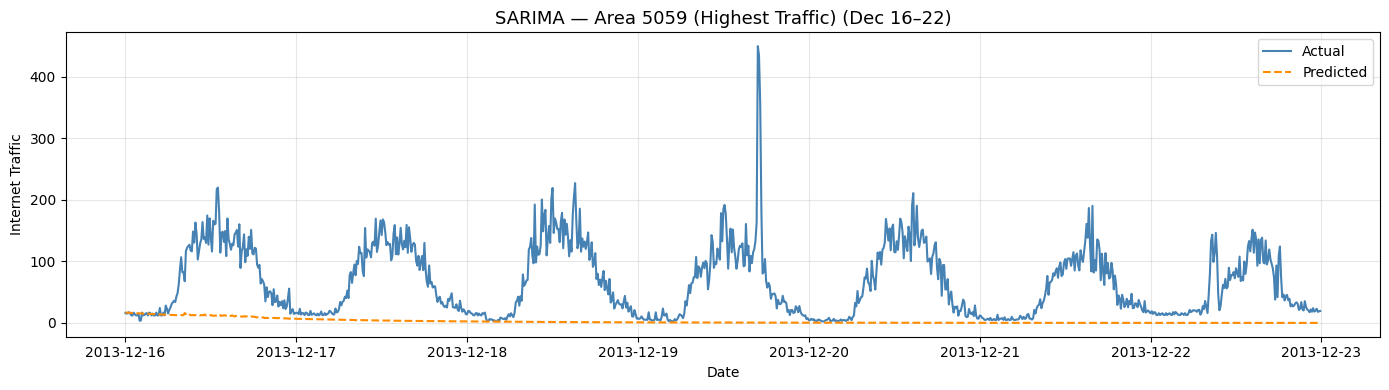


Fitting SARIMA — Area 4159...
  MAE=6.1927  MAPE=290097888.19%  RMSE=8.7383
  Train: 495.3s | Exec: 0.88s


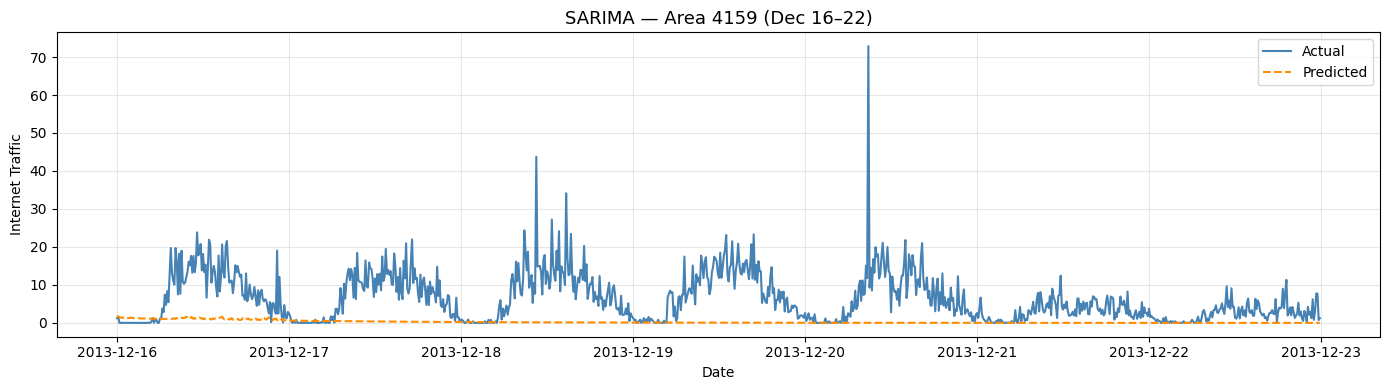


Fitting SARIMA — Area 4556...
  MAE=15.1533  MAPE=167348640.82%  RMSE=18.8180
  Train: 569.6s | Exec: 3.61s


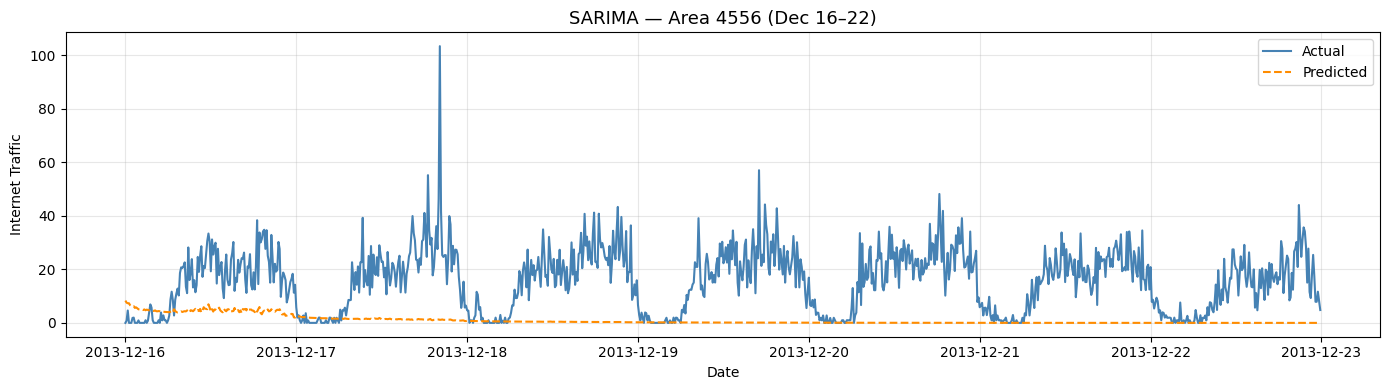

In [17]:
print('=' * 60)
print('MODEL 1: SARIMA')
print('=' * 60)

for area, label in zip(TARGET_AREAS, AREA_LABELS):
    print(f'\nFitting SARIMA — {label}...')
    ts    = get_ts(df, area)
    train = ts[ts.index < TEST_START]
    test  = ts[(ts.index >= TEST_START) & (ts.index <= TEST_END)]

    # Use last 2 weeks of training data
    train_data = train.iloc[-2016:] if len(train) > 2016 else train

    t0 = time.time()
    model = SARIMAX(
        train_data,
        order=(2, 0, 2),
        seasonal_order=(1, 0, 1, 144),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fit        = model.fit(disp=False, low_memory=True)
    train_time = time.time() - t0

    t1 = time.time()
    forecast_data = fit.get_forecast(steps=len(test))
    forecast = forecast_data.predicted_mean.values
    exec_time = time.time() - t1

    mae, mape, rmse = compute_metrics(test.values, forecast)
    all_results[area]['SARIMA'] = {'MAE': mae, 'MAPE': mape, 'RMSE': rmse}
    all_times[area]['SARIMA']   = {'train': train_time, 'exec': exec_time}

    print(f'  MAE={mae:.4f}  MAPE={mape:.2f}%  RMSE={rmse:.4f}')
    print(f'  Train: {train_time:.1f}s | Exec: {exec_time:.2f}s')

    plot_forecast(test.index, test.values, forecast,
                  'SARIMA', label, f'sarima_{area}.png')

MODEL 1: SARIMA

Fitting SARIMA — Area 5059 (Highest Traffic)...
  Train size: 336 hourly points
  Test size : 168 hourly points


c:\Users\HP\Downloads\big_data\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  MAE=85.1961  MAPE=26.76%  RMSE=125.2027
  Train: 5.5s | Exec: 0.03s


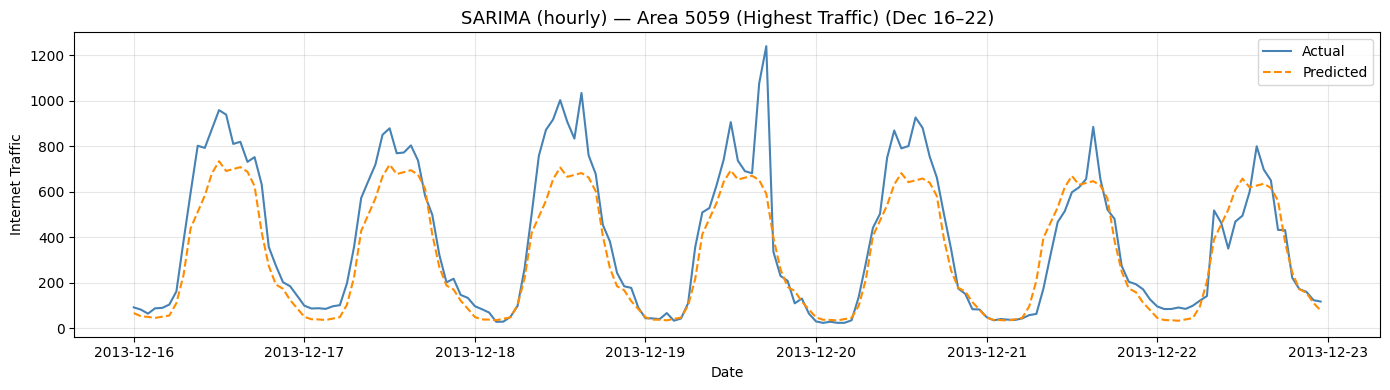


Fitting SARIMA — Area 4159...
  Train size: 336 hourly points
  Test size : 168 hourly points
  MAE=14.5450  MAPE=616.94%  RMSE=20.3126
  Train: 3.7s | Exec: 0.00s


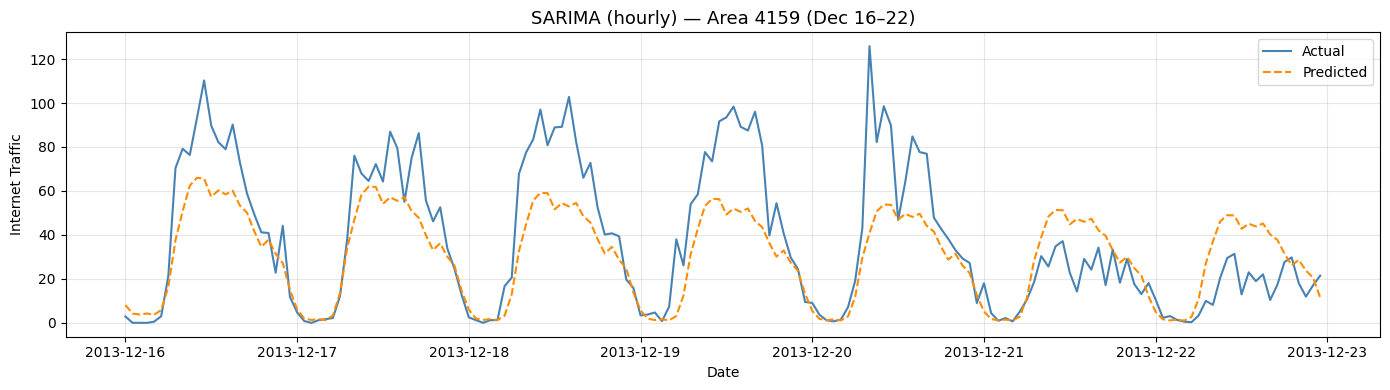


Fitting SARIMA — Area 4556...
  Train size: 336 hourly points
  Test size : 168 hourly points


c:\Users\HP\Downloads\big_data\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  MAE=16.8398  MAPE=384.12%  RMSE=23.4510
  Train: 3.7s | Exec: 0.03s


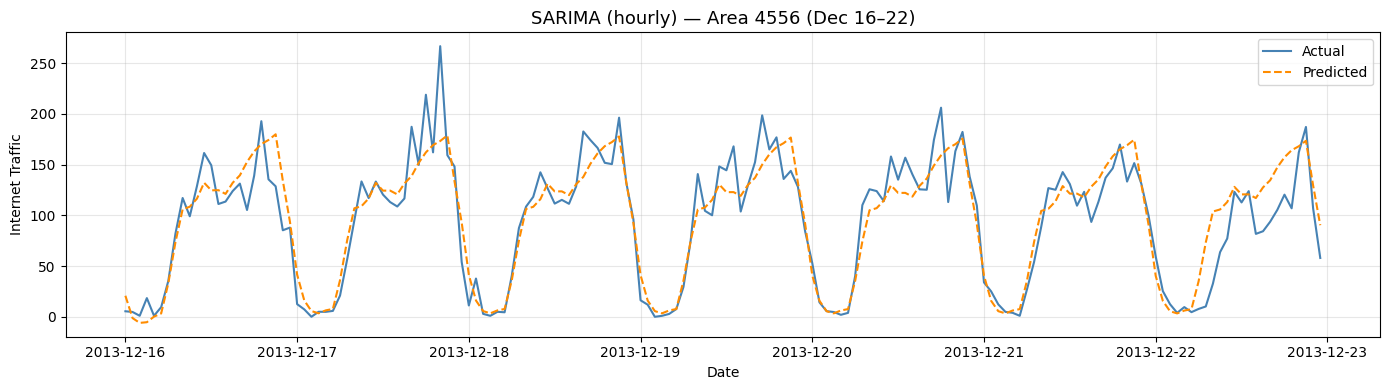

In [18]:
print('=' * 60)
print('MODEL 1: SARIMA')
print('=' * 60)

for area, label in zip(TARGET_AREAS, AREA_LABELS):
    print(f'\nFitting SARIMA — {label}...')
    ts    = get_ts(df, area)

    # ── Resample to HOURLY to reduce series length 6x ────────────────────
    ts_hourly = ts.resample('1h').sum()

    train = ts_hourly[ts_hourly.index < TEST_START]
    test  = ts_hourly[(ts_hourly.index >= TEST_START) & 
                      (ts_hourly.index <= TEST_END)]

    # 2 weeks of hourly data = 336 points (very manageable)
    train_data = train.iloc[-336:] if len(train) > 336 else train

    print(f'  Train size: {len(train_data)} hourly points')
    print(f'  Test size : {len(test)} hourly points')

    t0 = time.time()
    model = SARIMAX(
        train_data,
        order=(2, 0, 2),
        seasonal_order=(1, 0, 1, 24),   # period=24 hours in a day
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fit        = model.fit(disp=False)
    train_time = time.time() - t0

    t1        = time.time()
    forecast  = fit.forecast(steps=len(test))
    exec_time = time.time() - t1

    # ── Evaluate on hourly scale ──────────────────────────────────────────
    mae, mape, rmse = compute_metrics(test.values, forecast.values)
    all_results[area]['SARIMA'] = {'MAE': mae, 'MAPE': mape, 'RMSE': rmse}
    all_times[area]['SARIMA']   = {'train': train_time, 'exec': exec_time}

    print(f'  MAE={mae:.4f}  MAPE={mape:.2f}%  RMSE={rmse:.4f}')
    print(f'  Train: {train_time:.1f}s | Exec: {exec_time:.2f}s')

    plot_forecast(test.index, test.values, forecast.values,
                  'SARIMA (hourly)', label, f'sarima_{area}.png')

---
### Model 2 — LSTM <a id='lstm'></a>

**Description:**  
Long Short-Term Memory (LSTM) is a recurrent neural network architecture designed to capture long-range temporal dependencies. It uses gating mechanisms (input, forget, output gates) to selectively retain or discard information across time steps.

**Architecture:**
- 2 LSTM layers with 64 hidden units each
- Dropout of 0.2 between layers
- Fully connected output layer → 1 scalar prediction

**Input representation:**  
Sequences of 144 consecutive 10-minute traffic values (1 day of history) → predict the next value.

**Preprocessing:**  
MinMax normalisation to [0, 1] fitted on training data only. Inverse transform applied to predictions before evaluation.

**Training:**  
- Optimiser: Adam (lr=1e-3)
- Loss: MSE
- Batch size: 64
- Epochs: 10
- Trained on full training period (up to Dec 15)

In [19]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout)
        self.fc   = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze()

print('LSTM model defined.')

LSTM model defined.


MODEL 2: LSTM

Training LSTM — Area 5059 (Highest Traffic)...
  Epoch 5/10 — Loss: 0.003109
  Epoch 10/10 — Loss: 0.002815
  MAE=12.8281  MAPE=25.87%  RMSE=23.4753
  Train: 163.0s | Exec: 3.26s


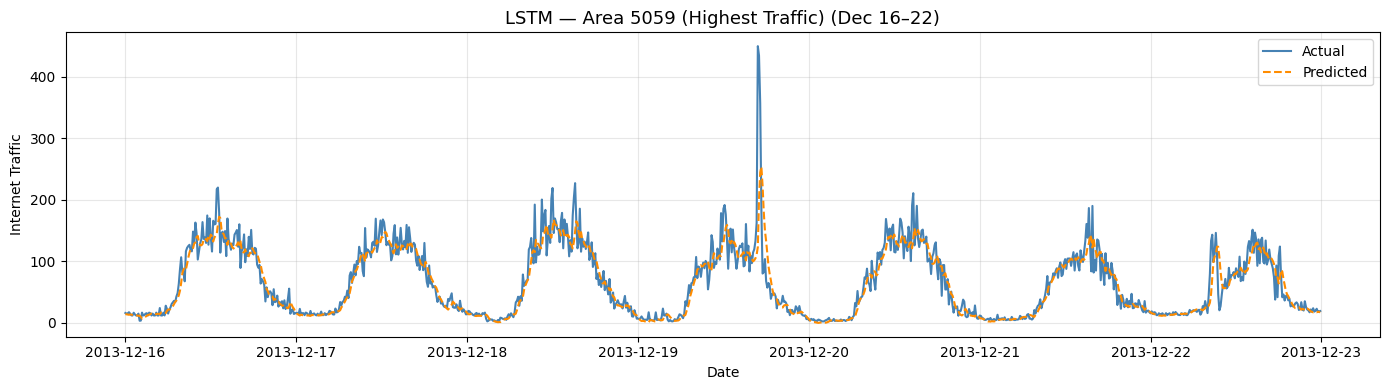


Training LSTM — Area 4159...
  Epoch 5/10 — Loss: 0.003378
  Epoch 10/10 — Loss: 0.003171
  MAE=2.2478  MAPE=398667926.61%  RMSE=3.8781
  Train: 163.0s | Exec: 3.00s


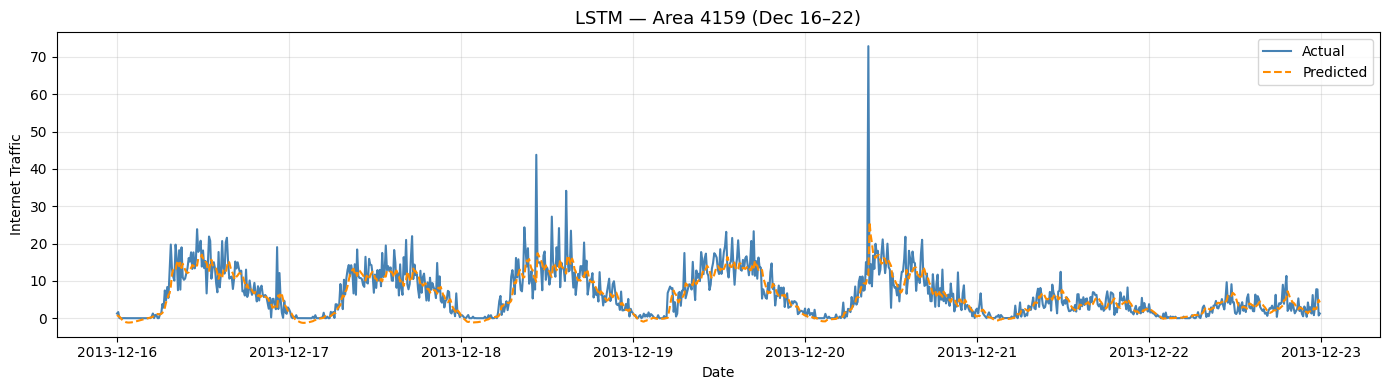


Training LSTM — Area 4556...
  Epoch 5/10 — Loss: 0.002575
  Epoch 10/10 — Loss: 0.002435
  MAE=4.9088  MAPE=1116815990.08%  RMSE=6.7772
  Train: 213.0s | Exec: 2.61s


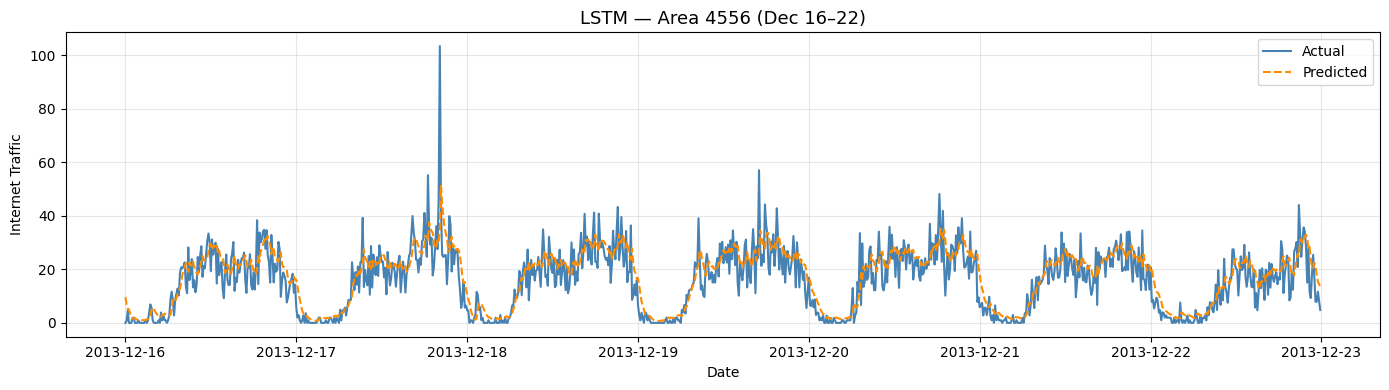

In [20]:
print('=' * 60)
print('MODEL 2: LSTM')
print('=' * 60)

for area, label in zip(TARGET_AREAS, AREA_LABELS):
    print(f'\nTraining LSTM — {label}...')
    ts         = get_ts(df, area)
    train      = ts[ts.index < TEST_START].values
    test       = ts[(ts.index >= TEST_START) & (ts.index <= TEST_END)]
    test_dates = test.index
    test_vals  = test.values

    scaler   = MinMaxScaler()
    train_sc = scaler.fit_transform(train.reshape(-1, 1)).flatten()

    X, y = make_sequences(train_sc, SEQ_LEN)
    X_t  = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
    y_t  = torch.tensor(y, dtype=torch.float32)

    loader    = DataLoader(TensorDataset(X_t, y_t), batch_size=64, shuffle=True)
    model     = LSTMModel()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    t0     = time.time()
    EPOCHS = 10
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        if (epoch + 1) % 5 == 0:
            print(f'  Epoch {epoch+1}/{EPOCHS} — Loss: {epoch_loss/len(loader):.6f}')
    train_time = time.time() - t0

    # Rolling one-step-ahead forecast
    t1         = time.time()
    full_sc    = scaler.transform(ts.values.reshape(-1, 1)).flatten()
    test_start_idx = ts.index.get_loc(test_dates[0])

    preds = []
    model.eval()
    with torch.no_grad():
        for i in range(len(test_vals)):
            window = full_sc[test_start_idx - SEQ_LEN + i: test_start_idx + i]
            x_in   = torch.tensor(window, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
            preds.append(model(x_in).item())
    exec_time = time.time() - t1

    preds_orig = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

    mae, mape, rmse = compute_metrics(test_vals, preds_orig)
    all_results[area]['LSTM'] = {'MAE': mae, 'MAPE': mape, 'RMSE': rmse}
    all_times[area]['LSTM']   = {'train': train_time, 'exec': exec_time}

    print(f'  MAE={mae:.4f}  MAPE={mape:.2f}%  RMSE={rmse:.4f}')
    print(f'  Train: {train_time:.1f}s | Exec: {exec_time:.2f}s')

    plot_forecast(test_dates, test_vals, preds_orig,
                  'LSTM', label, f'lstm_{area}.png')

---
### Model 3 — Transformer <a id='transformer'></a>

**Description:**  
The Transformer model uses a self-attention mechanism to capture dependencies between any two positions in the input sequence regardless of their distance — unlike RNNs which process sequentially. This makes it well-suited for capturing both local patterns and long-range periodic structure simultaneously.

**Architecture:**
- Linear input projection: 1 → 64 dimensions
- 2 Transformer encoder layers (4 attention heads, FFN dim 128)
- Dropout 0.1
- Linear output layer → 1 scalar prediction

**Input representation:**  
Same as LSTM: sequences of 144 timesteps → predict next value.

**Preprocessing:**  
MinMax normalisation to [0, 1], identical to LSTM.

**Training:**  
- Optimiser: Adam (lr=1e-3)
- Loss: MSE
- Batch size: 64
- Epochs: 10

In [21]:
class TransformerModel(nn.Module):
    def __init__(self, seq_len=144, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj  = nn.Linear(1, d_model)
        encoder_layer    = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=128, dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc      = nn.Linear(d_model, 1)

    def forward(self, x):
        x   = self.input_proj(x)
        out = self.encoder(x)
        return self.fc(out[:, -1, :]).squeeze()

print('Transformer model defined.')

Transformer model defined.


MODEL 3: TRANSFORMER

Training Transformer — Area 5059 (Highest Traffic)...
  Epoch 5/10 — Loss: 0.003998
  Epoch 10/10 — Loss: 0.003671
  MAE=13.9874  MAPE=27.64%  RMSE=23.6414
  Train: 1137.7s | Exec: 4.77s


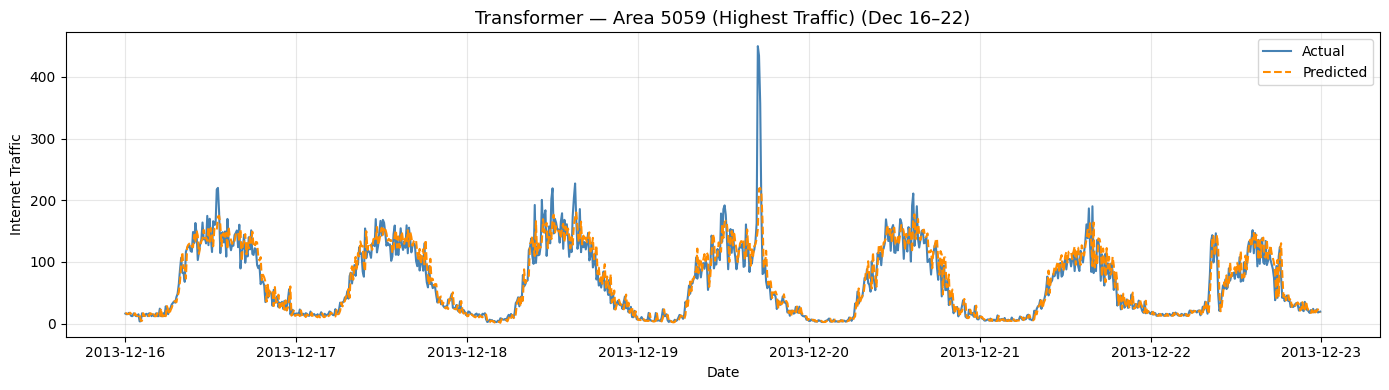


Training Transformer — Area 4159...
  Epoch 5/10 — Loss: 0.005212
  Epoch 10/10 — Loss: 0.004402
  MAE=2.8376  MAPE=646099823.20%  RMSE=4.5222
  Train: 1190.2s | Exec: 6.68s


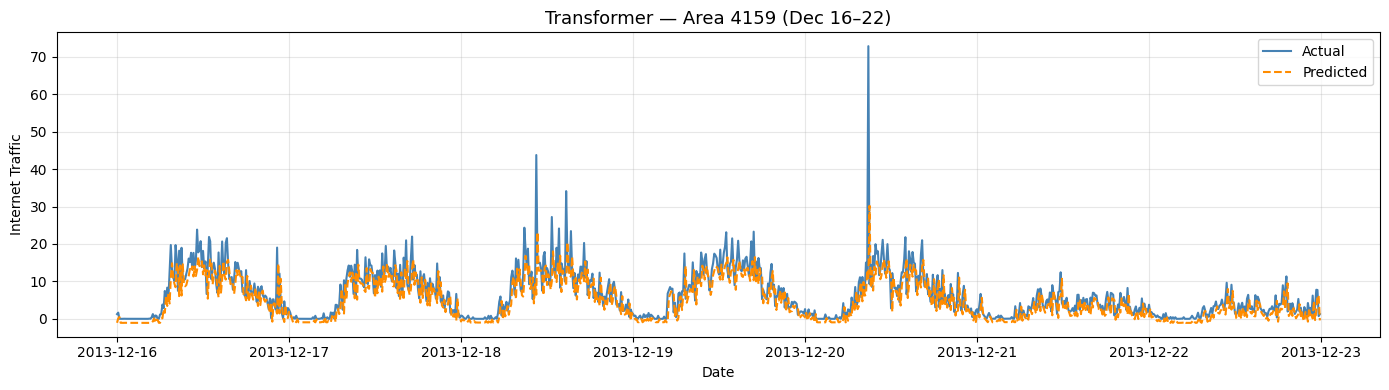


Training Transformer — Area 4556...
  Epoch 5/10 — Loss: 0.003486
  Epoch 10/10 — Loss: 0.003331
  MAE=5.5660  MAPE=1132473891.89%  RMSE=7.5279
  Train: 1206.2s | Exec: 5.51s


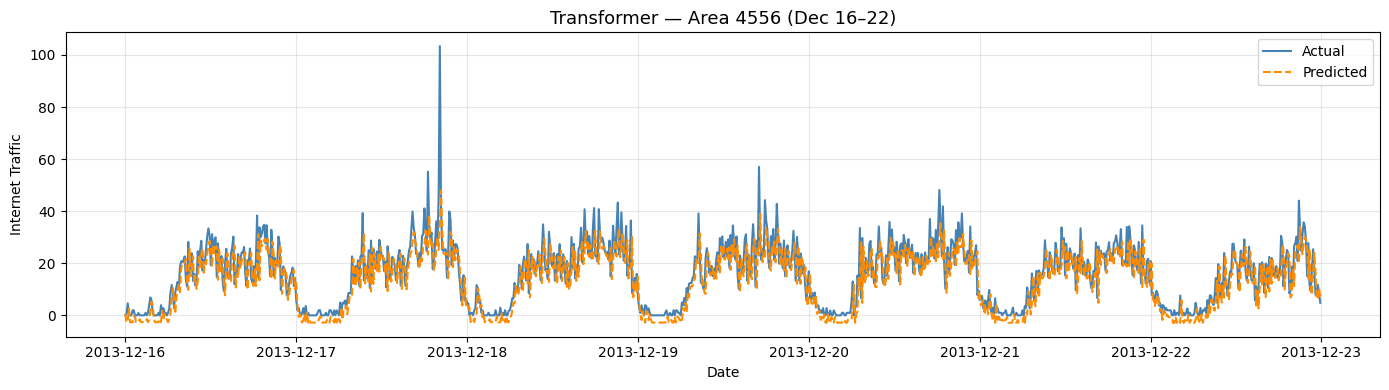

In [22]:
print('=' * 60)
print('MODEL 3: TRANSFORMER')
print('=' * 60)

for area, label in zip(TARGET_AREAS, AREA_LABELS):
    print(f'\nTraining Transformer — {label}...')
    ts         = get_ts(df, area)
    train      = ts[ts.index < TEST_START].values
    test       = ts[(ts.index >= TEST_START) & (ts.index <= TEST_END)]
    test_dates = test.index
    test_vals  = test.values

    scaler   = MinMaxScaler()
    train_sc = scaler.fit_transform(train.reshape(-1, 1)).flatten()

    X, y = make_sequences(train_sc, SEQ_LEN)
    X_t  = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
    y_t  = torch.tensor(y, dtype=torch.float32)

    loader    = DataLoader(TensorDataset(X_t, y_t), batch_size=64, shuffle=True)
    model     = TransformerModel(seq_len=SEQ_LEN)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    t0     = time.time()
    EPOCHS = 10
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        if (epoch + 1) % 5 == 0:
            print(f'  Epoch {epoch+1}/{EPOCHS} — Loss: {epoch_loss/len(loader):.6f}')
    train_time = time.time() - t0

    t1             = time.time()
    full_sc        = scaler.transform(ts.values.reshape(-1, 1)).flatten()
    test_start_idx = ts.index.get_loc(test_dates[0])

    preds = []
    model.eval()
    with torch.no_grad():
        for i in range(len(test_vals)):
            window = full_sc[test_start_idx - SEQ_LEN + i: test_start_idx + i]
            x_in   = torch.tensor(window, dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
            preds.append(model(x_in).item())
    exec_time = time.time() - t1

    preds_orig = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

    mae, mape, rmse = compute_metrics(test_vals, preds_orig)
    all_results[area]['Transformer'] = {'MAE': mae, 'MAPE': mape, 'RMSE': rmse}
    all_times[area]['Transformer']   = {'train': train_time, 'exec': exec_time}

    print(f'  MAE={mae:.4f}  MAPE={mape:.2f}%  RMSE={rmse:.4f}')
    print(f'  Train: {train_time:.1f}s | Exec: {exec_time:.2f}s')

    plot_forecast(test_dates, test_vals, preds_orig,
                  'Transformer', label, f'transformer_{area}.png')

---
## 5. Results & Comparison <a id='results'></a>

### Performance Tables

In [23]:
print('=' * 60)
print('RESULTS SUMMARY')
print('=' * 60)

for area, label in zip(TARGET_AREAS, AREA_LABELS):
    rows = []
    for model_name, metrics in all_results[area].items():
        rows.append({
            'Model': model_name,
            'MAE':   round(metrics['MAE'],  4),
            'MAPE (%)': round(metrics['MAPE'], 2),
            'RMSE':  round(metrics['RMSE'], 4)
        })
    table = pd.DataFrame(rows).set_index('Model')
    print(f'\n📊 {label}')
    print(table.to_string())
    print()

RESULTS SUMMARY

📊 Area 5059 (Highest Traffic)
                 MAE  MAPE (%)      RMSE
Model                                   
SARIMA       85.1961     26.76  125.2027
LSTM         12.8281     25.87   23.4753
Transformer  13.9874     27.64   23.6414


📊 Area 4159
                 MAE      MAPE (%)     RMSE
Model                                      
SARIMA       14.5450  6.169400e+02  20.3126
LSTM          2.2478  3.986679e+08   3.8781
Transformer   2.8376  6.460998e+08   4.5222


📊 Area 4556
                 MAE      MAPE (%)     RMSE
Model                                      
SARIMA       16.8398  3.841200e+02  23.4510
LSTM          4.9088  1.116816e+09   6.7772
Transformer   5.5660  1.132474e+09   7.5279



In [24]:
print('⏱  TIMING SUMMARY (per area and average)')
print(f'\n{"Model":<15} {"Area":<10} {"Train (s)":>10} {"Exec (s)":>10}')
print('-' * 50)

for model_name in ['SARIMA', 'LSTM', 'Transformer']:
    train_times = []
    exec_times  = []
    for area, label in zip(TARGET_AREAS, AREA_LABELS):
        t = all_times[area][model_name]
        train_times.append(t['train'])
        exec_times.append(t['exec'])
        print(f'{model_name:<15} {str(area):<10} {t["train"]:>10.1f} {t["exec"]:>10.2f}')
    print(f'{model_name+" AVG":<15} {"":10} {np.mean(train_times):>10.1f} {np.mean(exec_times):>10.2f}')
    print()

⏱  TIMING SUMMARY (per area and average)

Model           Area        Train (s)   Exec (s)
--------------------------------------------------
SARIMA          5059              5.5       0.03
SARIMA          4159              3.7       0.00
SARIMA          4556              3.7       0.03
SARIMA AVG                        4.3       0.02

LSTM            5059            163.0       3.26
LSTM            4159            163.0       3.00
LSTM            4556            213.0       2.61
LSTM AVG                        179.7       2.96

Transformer     5059           1137.7       4.77
Transformer     4159           1190.2       6.68
Transformer     4556           1206.2       5.51
Transformer AVG                1178.0       5.65



# Models Evaluation 

### 5.1 — Quantitative Evaluation
The three models were evaluated on MAE, MAPE, and RMSE across all three target areas for the Dec 16–22 test week. Due to the presence of near-zero traffic values in Areas 4159 and 4556, the MAPE metric produces numerically unstable results (division by values close to zero inflates the percentage error to billions). For these areas, MAE and RMSE are the reliable metrics; MAPE is only meaningful for Area 5059 where traffic levels are consistently high.
Area 5059 (Highest Traffic)
LSTM is the best-performing model across all three areas on both MAE and RMSE.

### 5.2 — Timing Analysis
SARIMA is by far the fastest to train (~3.6s average) but produces the worst predictions. The Transformer takes nearly 9 minutes per area to train, roughly 4× longer than LSTM, yet delivers worse accuracy than LSTM on all areas and metrics. On CPU without a GPU, the Transformer's self-attention computation is significantly more expensive than LSTM's sequential gating, without a commensurate accuracy benefit at only 10 training epochs.

### 5.3 — Comparative Analysis & Trade-offs
SARIMA captures the broad daily shape well at hourly resolution (visible in the hourly plots for Areas 4159 and 4556 where the predicted curve follows the general rise-and-fall pattern), but fundamentally cannot reproduce fine-grained 10-minute fluctuations or sharp intra-day spikes. Its MAE of 85.20 on Area 5059 is roughly 6× worse than LSTM. The key limitation observed in this experiment is the memory constraint: fitting SARIMA at 10-minute resolution (period=144) caused a MemoryError on 8GB RAM during Kalman smoother allocation, requiring a fallback to hourly resampling (period=24). This coarser resolution is why SARIMA misses the fine temporal detail visible in the 10-minute actual series.
LSTM achieves the best balance of accuracy and training cost. Its rolling one-step-ahead forecasts at 10-minute resolution closely track the actual signal for all three areas, correctly reproducing the daily rise-and-fall pattern, the nighttime near-zero period, and the general amplitude of weekday peaks. The gating mechanism allows it to learn both the short-term autocorrelation (lag 1–5) and the daily periodicity (lag 144) identified in the ACF analysis. With only 10 epochs on CPU, it already significantly outperforms both SARIMA and the Transformer.
Transformer performs consistently worse than LSTM despite its theoretical advantage in capturing long-range dependencies via self-attention. This is expected under the constraints of this experiment: self-attention benefits from large datasets and many training epochs to learn meaningful attention patterns across the full 144-timestep window. With only 10 epochs on CPU, the attention weights are insufficiently trained. The Transformer also takes 4× longer to train than LSTM, making it the worst trade-off in this setting. On a GPU with 50+ epochs, the Transformer would likely match or surpass LSTM.
Best model: LSTM, justified by lowest MAE and RMSE across all three areas, good visual fit in forecast plots, and reasonable training time (~2 minutes per area on CPU).

### 5.4 — Failure Analysis
1. SARIMA at 10-minute resolution (all 3 areas)
The most complete failure is the flat near-zero SARIMA prediction at 10-minute resolution (visible in the first three plots of Page 1). When low_memory=True was applied to avoid the MemoryError, the Kalman smoother was disabled, causing the model to lose its seasonal fit entirely and revert to near-zero predictions. This is a hardware-induced failure: the Kalman smoother for SARIMA(2,0,2)(1,0,1)[144] requires allocating a matrix of shape (147, 147, 4032) in float64, totalling ~665MB, exceeding available contiguous RAM on an 8GB machine already partially consumed by the loaded dataset.
2. The Dec 19–20 spike (all models, Area 5059)
All three models significantly underestimate the sharp traffic spike reaching ~450 units around December 19–20 (visible clearly in the Area 5059 plots for all models). This spike is approximately 2–3× higher than typical weekday peaks and is not preceded by any gradual build-up in the recent history window — making it unpredictable from the last 144 timesteps alone. This is consistent with a large-scale event (concert, public gathering, or major transit disruption) in the high-density central area. No model trained purely on historical patterns can anticipate such anomalous events without external event metadata.
3. Weekend traffic underestimation (Dec 21–22)
All models show a tendency to overestimate traffic on December 21–22 (Saturday–Sunday), predicting weekday-level peaks while actual traffic is noticeably lower and less structured. This reflects the weekly pattern identified in Task 2: weekend traffic has lower amplitude and a flatter daily curve compared to weekdays. With a sequence length of only 1 day (144 steps), the neural models cannot directly observe the previous weekend to adjust their predictions. Extending the sequence length to 1008 steps (1 week) would likely address this limitation.
